In [1]:
## Importando dependências principais
# Incluímos matplotlib para visualização e numpy para operações numéricas.
import matplotlib.pyplot as plt
import numpy as np


In [2]:
from starforge.cosmology import LCDMModel
from starforge.cosmology import CosmologicalParameters
from starforge.structures import PressSchechterMF, ShethTormenMF
from starforge.structures import Perturbations
from starforge.structures import  Sigma
from starforge.structures import HaloBaryonAccretion

## Definindo parâmetros cosmológicos (exemplo Planck 2018)
params = CosmologicalParameters(
    omegam=0.24,
    omegab=0.04,
    omegal=0.73,
    h=0.7   
)
zmax = 20
lcdm = LCDMModel(params)

pert = Perturbations(lcdm)

sigma = Sigma(pert)

## Criando função de massa de halos
# Usamos HalosMassFunction, que depende de Sigma e Perturbations internamente.

sigma_functions = sigma.initialize_sigma_cache(
    zmax=zmax,
    mass_function_type="ST",  # Sheth-Tormen, por exemplo
    lmin=6.0,                 # log10(M_min / Msun)
    lmax=18.0,                # log10(M_max / Msun)
    dinamicLimits=True,
)

# mass_function = ShethTormenMF(lcdm, pert, sigma_functions)
mass_function = PressSchechterMF(lcdm, pert, sigma_functions)


hba = HaloBaryonAccretion(mass_function, zmax=zmax)

In [3]:
## Exemplo: número total de halos em função do redshift
# Usamos halos_n(z) para integrar a função de massa sobre todas as massas.
z_values = np.linspace(2.2, 2.6, 20)
n_halos = [hba.halos_n(z) for z in z_values]



6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0


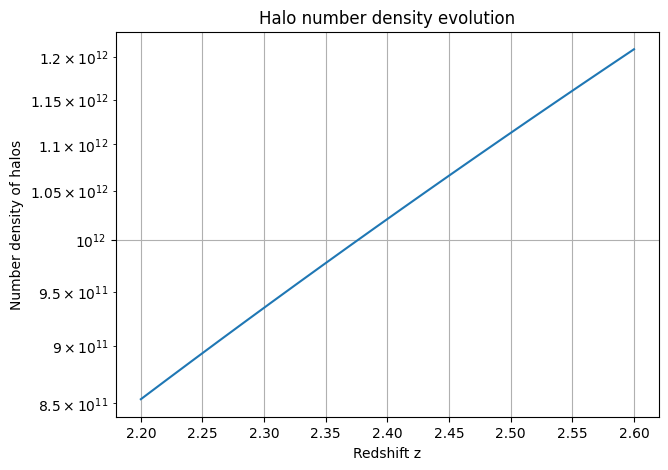

In [4]:
plt.figure(figsize=(7,5))
plt.plot(z_values, n_halos)
plt.xlabel("Redshift z")
plt.yscale("log")
plt.ylabel("Number density of halos")
plt.title("Halo number density evolution")
plt.grid(True)
plt.show()


In [5]:
## Exemplo: fração bariônica ligada a estruturas
# Usamos fbstruc(z), que é a razão entre halos_n(z) e a densidade de matéria escura.
rodm = [lcdm.rodm(z) for z in z_values]

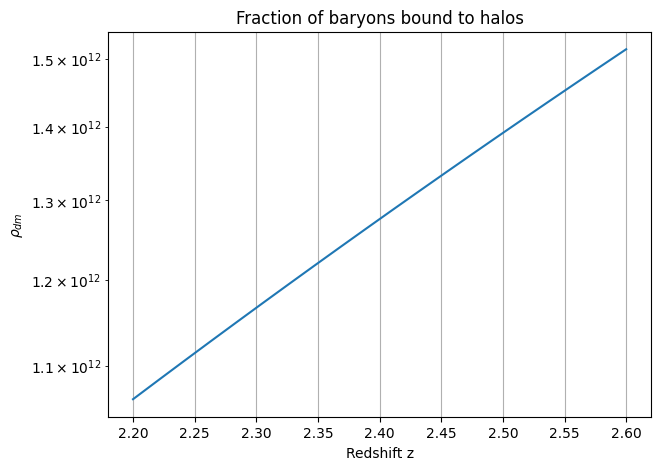

In [6]:
plt.figure(figsize=(7,5))
plt.plot(z_values, rodm, label=r"$\rho_{dm}$")
plt.xlabel("Redshift z")
plt.ylabel(r"$\rho_{dm}$")
plt.yscale("log")
plt.title("Fraction of baryons bound to halos")
plt.grid(True)
plt.show()

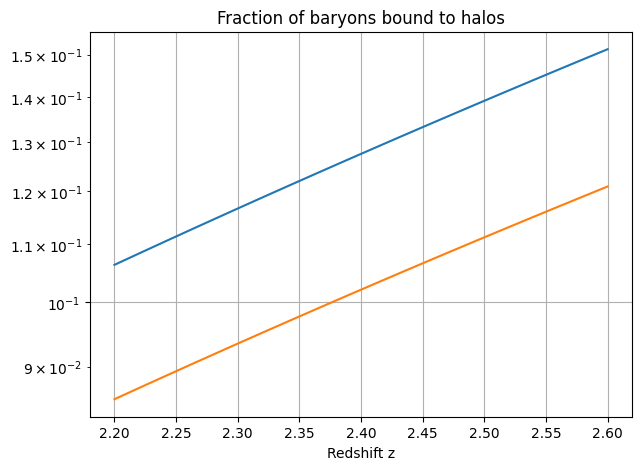

In [7]:
plt.figure(figsize=(7,5))
plt.plot(z_values, np.array(rodm) / 1e13, label=r"$\rho_{dm}$")
plt.plot(z_values, np.array(n_halos)/1e13)
plt.xlabel("Redshift z")
plt.yscale("log")
# plt.ylim([0, 0.8])
plt.title("Fraction of baryons bound to halos")
plt.grid(True)
plt.show()

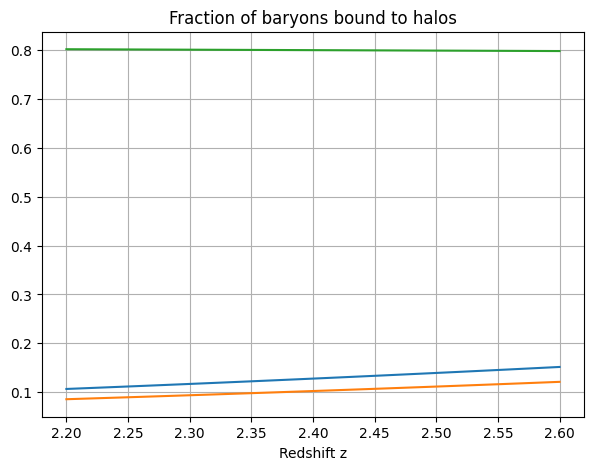

In [8]:
plt.figure(figsize=(7,5))
plt.plot(z_values, np.array(rodm) / 1e13, label=r"$\rho_{dm}$")
plt.plot(z_values, np.array(n_halos)/1e13)
plt.plot(z_values, np.array(n_halos)/np.array(rodm) )
plt.xlabel("Redshift z")
# plt.yscale("log")
# plt.ylim([0, 0.8])
plt.title("Fraction of baryons bound to halos")
plt.grid(True)
plt.show()

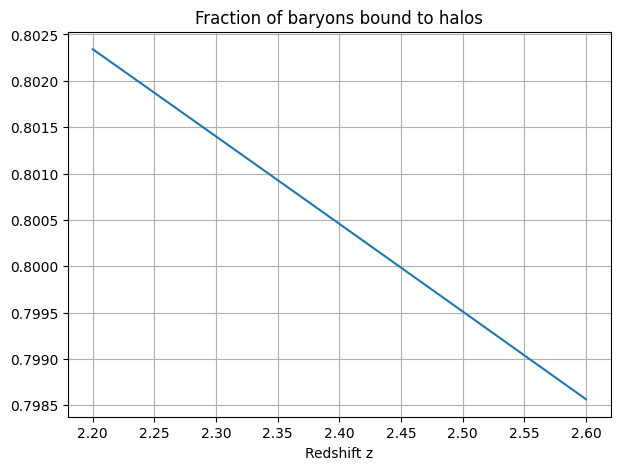

In [9]:
plt.figure(figsize=(7,5))
plt.plot(z_values, np.array(n_halos)/np.array(rodm) )
plt.xlabel("Redshift z")
# plt.yscale("log")
# plt.ylim([0, 0.8])
plt.title("Fraction of baryons bound to halos")
plt.grid(True)
plt.show()

In [10]:
## Exemplo: fração bariônica ligada a estruturas
# Usamos fbstruc(z), que é a razão entre halos_n(z) e a densidade de matéria escura.
fb_values = [hba.fbstruc(z) for z in z_values]
fb2 = [hba.halos_n(z)/ lcdm.rodm(z) for z in z_values]

6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0


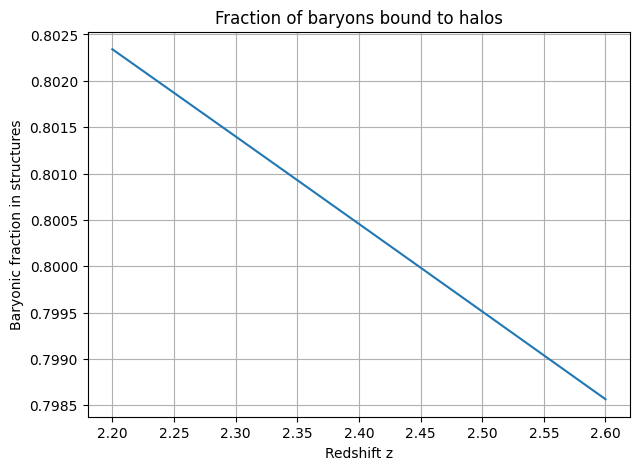

In [11]:
plt.figure(figsize=(7,5))
# plt.plot(z_values, fb_values, label="In class")
plt.plot(z_values, fb2, label="in Hand")
plt.xlabel("Redshift z")
plt.ylabel("Baryonic fraction in structures")
# plt.yscale("log")
# plt.ylim([0, 0.8])
plt.title("Fraction of baryons bound to halos")
plt.grid(True)
plt.show()

In [12]:
## Calculando a taxa de acreção bariônica
# Este método preenche internamente _ascale, _abt2 e o spline tck_ab.
hba.start_baryonic_accretion_rate()

6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6.0 18.0
6

In [13]:
ab = [hba.abt(1/(1+z)) for z in z_values]

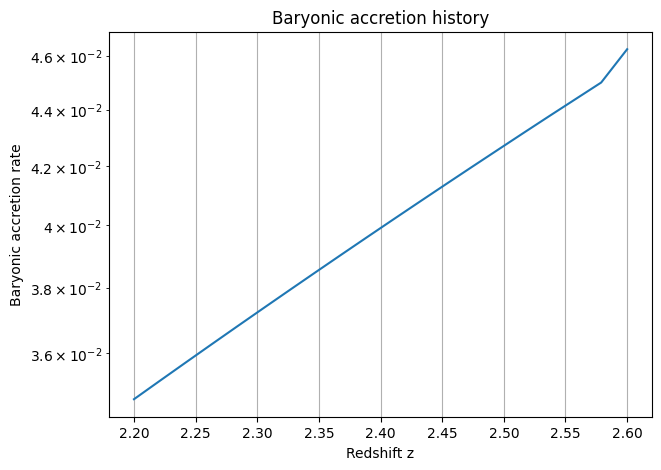

In [14]:
plt.figure(figsize=(7,5))
plt.plot(z_values, ab)
plt.xlabel("Redshift z")
plt.ylabel("Baryonic accretion rate")
plt.yscale("log")
plt.title("Baryonic accretion history")
plt.grid(True)
plt.show()

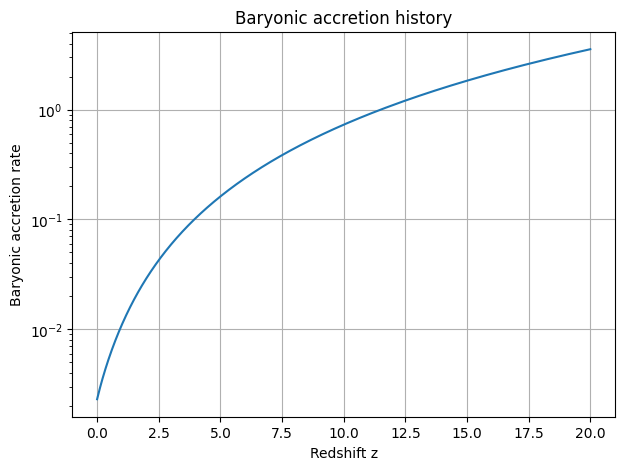

In [15]:
plt.figure(figsize=(7,5))
plt.plot(1/hba.ascale -1, hba.abt2)
plt.xlabel("Redshift z")
plt.ylabel("Baryonic accretion rate")
plt.yscale("log")
plt.title("Baryonic accretion history")
plt.grid(True)
plt.show()


In [16]:
## Consulta direta via spline
# Usamos abt(a) para recuperar a taxa de acreção em um valor específico de escala.
a_test = 0.5  # correspondente a z ≈ 1
print(f"A(baryonic accretion rate) at a={a_test}: {hba.abt(a_test)}")


A(baryonic accretion rate) at a=0.5: 0.011215023753225964
